# 04 Brain-Inspired Coreset Selection
This is the core algorithm of the project. We define data utility (redundancy filtering) via two bio-inspired lenses:
1. **Predictive Coding (Temporal):** We drop highly predictable frames (idle or linear movement).
2. **RAS (Distributional):** We cluster features and force diversity to simulate reticular formation novelty selection.

In [4]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(os.path.abspath('..'))

from src.data_utils import load_aloha_dataset
from src.coreset.select import select_coreset

# Load cached features and dataset
feature_path = os.path.abspath('../results/features_resnet18.pt')
features_dict = torch.load(feature_path, weights_only=True)
dataset = load_aloha_dataset()

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

## 1. Run Selection Algorithm
We are selecting the top 5 distinct demonstrations to achieve our target 10% coreset capacity.

In [5]:
alpha = 0.5  # Equal weight to temporal variance and distribution diversity
k = 5

selected_episodes, final_scores, temp_scores, dist_scores = select_coreset(
    dataset, features_dict, k=k, alpha=alpha
)

print(f"Selected Top-{k} Episodes: {selected_episodes}")

Computing temporal scores (Alpha=0.5)...
Computing distributional scores...
Selected Top-5 Episodes: [8, 6, 32, 42, 10]


## 2. Visualize Mechanisms
Let's see how our filters scored each episode, to ensure the definition of redundancy mathematically holds.

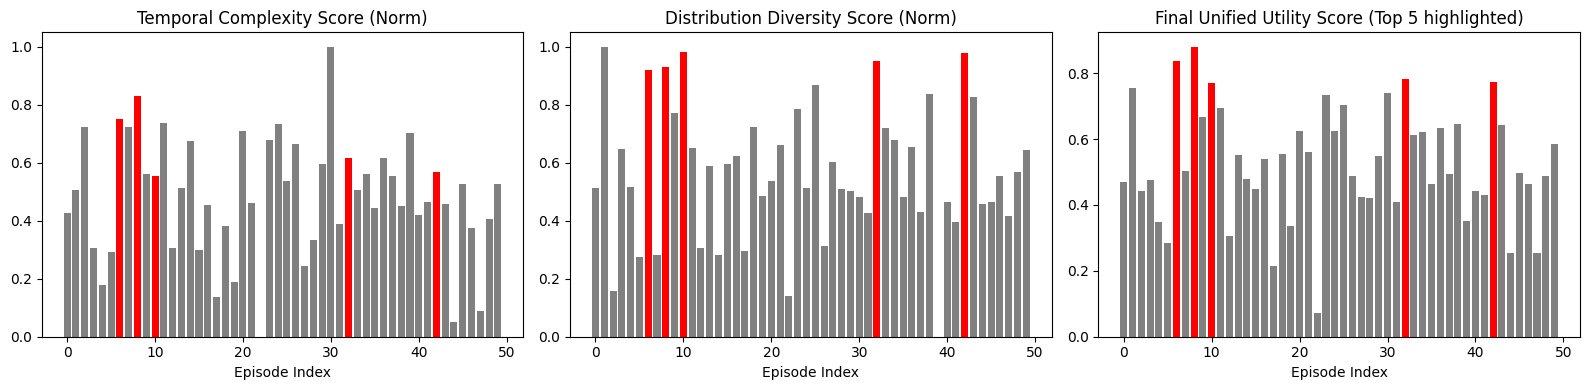

In [6]:
# Build visualization dataframe
eps = sorted(list(final_scores.keys()))
t_vals = [temp_scores[e] for e in eps]
d_vals = [dist_scores.get(e, 0) for e in eps]
f_vals = [final_scores[e] for e in eps]
colors = ['red' if e in selected_episodes else 'gray' for e in eps]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Temporal (Predictive Coding Proxy)
axes[0].bar(eps, t_vals, color=colors)
axes[0].set_title("Temporal Complexity Score (Norm)")
axes[0].set_xlabel("Episode Index")

# 2. Distributional (RAS Proxy)
axes[1].bar(eps, d_vals, color=colors)
axes[1].set_title("Distribution Diversity Score (Norm)")
axes[1].set_xlabel("Episode Index")

# 3. Final Combined Utilities
axes[2].bar(eps, f_vals, color=colors)
axes[2].set_title("Final Unified Utility Score (Top 5 highlighted)")
axes[2].set_xlabel("Episode Index")

plt.tight_layout()
plt.show()